# "Get paid for insurance you sell yourself" — does put-writing actually beat just owning stocks? 🎯
### The CBOE PUT-write pitch, tested on the one fund that actually does it

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Truncated_beta%3F: Confirmed](https://img.shields.io/badge/Truncated_beta%3F-Confirmed-8b949e?style=flat-square)

Every option-income newsletter has some version of this trade: sell a put on the S&P 500 every month, collect the premium, and if the market falls you just end up buying stocks at a discount anyway. "You get paid whether the market goes up, down, or sideways." The academic version has a real name — the **variance risk premium** — and a real, tradable wrapper: **PUTW**, an ETF that has done exactly this, live, since February 2016.

So: does it work? Not "is the premium real in theory" — does the actual fund, over its actual decade, actually beat just buying the index?

> 📓 **Plain-language layer.** Want the CAPM regression, the crash-beta interaction and the bootstrap? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** PUTW's *entire* live history (2016-02-24 → 2026-06-30) against SPY, with BIL (T-bills) as cash. We don't borrow the untradeable 1986→ CBOE PUT index's longer, friendlier sample — that would credit a return nobody could have banked. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from put_write_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    RET = st.daily_returns(PX)
    EX = st.excess(RET, cash_col=data.CASH)
else:
    PX = RET = EX = None
print("real cache present:", HAVE_REAL, "| joint trading days:", (0 if PX is None else len(PX)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2016-02-24', 'end': '2026-06-30', 'n': 2600, 'n_rows': 2601, 'putw_excess_ann': 6.78, 'putw_excess_t': 2.0, 'spy_excess_ann': 14.26, 'spy_excess_t': 2.9, 'gap_ann': -7.48, 'gap_t': -3.21, 'sharpe_putw': 0.53, 'sharpe_spy': 0.8, 'sharpe_gap': -0.27, 'boot_lo': -0.48, 'boot_hi': -0.0, 'boot_win_pct': 2.4, 'alpha_ann': -1.78, 'alpha_t': -0.95, 'beta': 0.6, 'beta_t': 10.26, 'cb_normal': 0.551, 'cb_normal_t': 14.05, 'cb_extra': 0.382, 'cb_extra_t': 2.34, 'cb_total': 0.932, 'n_crash_days': 33, 'volm_putw': -8.2, 'volm_spy': -10.1, 'covid_putw': -28.4, 'covid_spy': -33.7, 'mdd_putw': -28.4, 'mdd_spy': -33.7, 'n_months': 124, 'n_up': 89, 'n_dn': 35, 'cap_up': 59.3, 'cap_dn': 65.8, 'worst_m_putw': -13.1, 'worst_m_spy': -12.5, 'worst_m_date': '2020-03', 'vol_putw': 12.7, 'vol_spy': 17.8, 'skew_putw': -1.8, 'skew_spy': -0.32, 'worst_d_putw': -10.51, 'worst_d_spy': -10.94, 'syn_null_t_mean': -0.53, 'syn_null_t_sd': 0.98, 'syn_null_fire': 1, 'syn_planted_alpha': 4.69, 'syn_planted_t': 4.25, 'fp': '3a3191a10828'}


real cache present: True | joint trading days: 2601


## The answer first

| Question | Answer |
|---|---|
| Did PUTW beat SPY, risk-adjusted, since 2016? | **No.** Sharpe **0.53 vs 0.80** — and the gap is statistically real (a bootstrap confidence interval that stays negative). |
| Is any of its return something *beyond* just holding less S&P 500? | **No.** Once you control for the fact that it moves about **60%** as much as the market, there's nothing left over — no measurable extra "premium." |
| Does the lower risk protect you in a crash? | **Only sometimes — and it fades exactly when you'd need it.** In an ordinary week PUTW moves about 55% as much as SPY; on the worst days in the whole sample that number jumps to **93%** — almost full market risk, right when a real diversifier should be doing its job. |
| So what did selling puts for a decade actually get you? | A smaller, less stable slice of the S&P 500 — one whose single worst month (**-13.1%**, March 2020) was actually *worse* than the S&P's own worst month (**-12.5%**), despite carrying less average risk. |

> The premium exists on paper. The fund that's supposed to bank it didn't.

## 1 · The claim

> *"Options are systematically overpriced for the risk they carry — sellers of insurance get compensated more than the insurance is actuarially 'worth.' Sell puts on the S&P every month, collect that premium, forever, and you'll do at least as well as buy-and-hold with a smoother ride."*

It's not a strawman: the CBOE has run an actual index on exactly this rule since 1986, and over that long sample it more or less matched the S&P's return at roughly two-thirds the volatility — a genuinely better historical Sharpe ratio. That's the steelman. The question is whether the fund you can actually *buy* today delivers the same thing.

## 2 · So what?

If put-writing really banks a distinct risk-adjusted premium, it's one of the cleanest "free lunches" in finance — a way to earn more per unit of risk than the market itself pays, just by selling options instead of buying stock. It would be a genuine alternative to a plain S&P 500 index fund, not just a repackaging of the same market exposure with extra steps and an expense ratio.

## 3 · How would we even know?

- **The vehicle.** PUTW's entire live history, **2016-02-24 → 2026-06-30** (2,600 trading days) — not the untradeable index, which has a much longer and friendlier sample nobody could have actually captured.
- **The comparison.** Sharpe ratio (return per unit of risk, both measured against T-bills) against SPY, with a statistical confidence interval on the gap — not just a single number that could flip in a friendlier slice of history.
- **The "just beta" check.** A regression that asks: once you account for the fact that PUTW simply moves *less* than the market, is there anything left over?
- **The crash check.** Does the 'moves less than the market' behavior hold up on the worst days, or does it quietly disappear exactly when it would matter?

## 4 · The teardown — let's actually look

**First, the scoreboard.** Ten years of writing puts vs ten years of just holding the index.

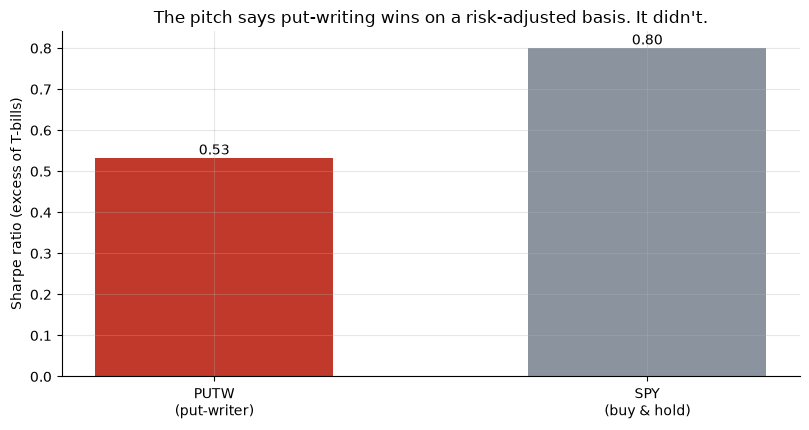

Sharpe PUTW 0.53  vs SPY 0.80


In [2]:
if HAVE_REAL:
    sh_p = st.sharpe_ann(EX['PUTW'].to_numpy())
    sh_s = st.sharpe_ann(EX['SPY'].to_numpy())
else:
    sh_p, sh_s = R['sharpe_putw'], R['sharpe_spy']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['PUTW\n(put-writer)', 'SPY\n(buy & hold)'], [sh_p, sh_s], color=[RED, GREY], width=.55)
for i, v in enumerate([sh_p, sh_s]): ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('Sharpe ratio (excess of T-bills)')
ax.set_title('The pitch says put-writing wins on a risk-adjusted basis. It didn\'t.')
plt.tight_layout(); plt.show()
print(f'Sharpe PUTW {sh_p:.2f}  vs SPY {sh_s:.2f}')

PUTW's Sharpe (**0.53**) trails SPY's (**0.80**) over the fund's entire life. A statistical test (in the quants notebook) confirms this isn't just noise — a bootstrap on the gap stays negative essentially every time you resample the decade.

**Next, the "is it just beta" check.** PUTW moves less than the market — is that the whole story?

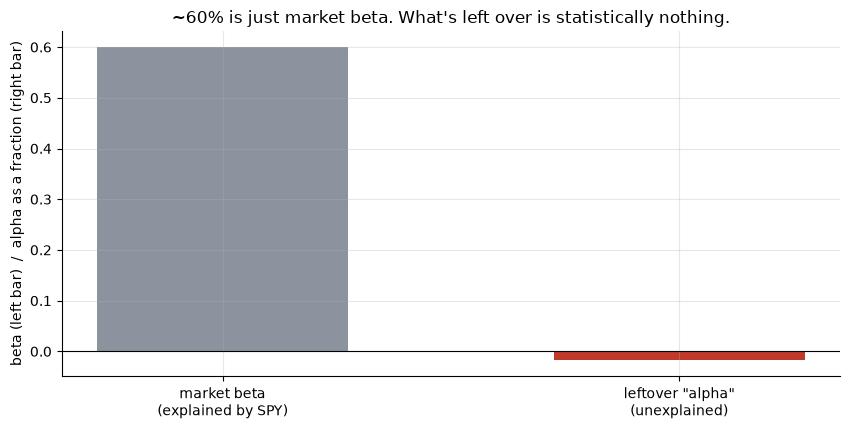

beta 0.60  alpha -1.78%/yr


In [3]:
if HAVE_REAL:
    cb = st.capm_alpha_beta(EX['PUTW'].to_numpy(), EX['SPY'].to_numpy())
    beta, alpha = cb['beta'], cb['alpha_ann_pct']
else:
    beta, alpha = R['beta'], R['alpha_ann']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['market beta\n(explained by SPY)', 'leftover "alpha"\n(unexplained)'],
       [beta, alpha/100], color=[GREY, RED], width=.55)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('beta (left bar)  /  alpha as a fraction (right bar)')
ax.set_title('~60% is just market beta. What\'s left over is statistically nothing.')
plt.tight_layout(); plt.show()
print(f'beta {beta:.2f}  alpha {alpha:+.2f}%/yr')

PUTW moves about **60%** as much as SPY on an average day — that's a real, strongly-measured number. What's left over after accounting for that beta is an "alpha" of **-1.78%/yr** that is **statistically indistinguishable from zero** — the point estimate is even slightly negative. There is no detectable premium beyond holding a smaller amount of stock.

**Finally, the crash check.** Does the 'lower risk' actually protect you when it counts?

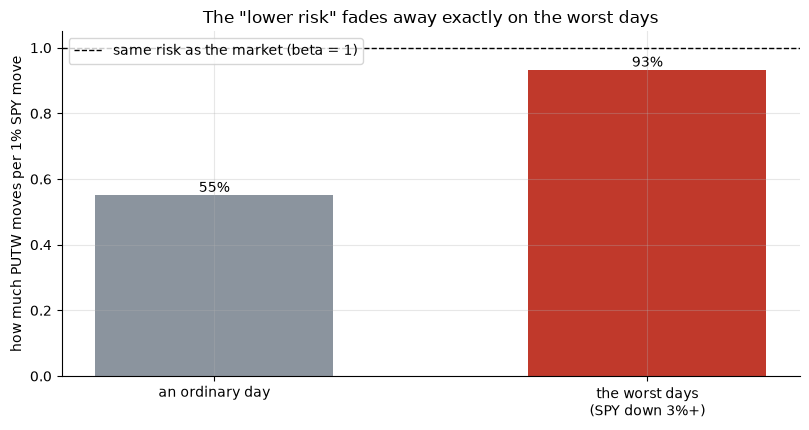

normal-day beta 0.55  crash-day beta 0.93


In [4]:
if HAVE_REAL:
    cx = st.crash_beta_interaction(EX['PUTW'].to_numpy(), EX['SPY'].to_numpy(),
                                    RET['SPY'].to_numpy(), threshold=data.CRASH_DAY_THRESHOLD)
    b_norm, b_crash = cx['beta_normal'], cx['crash_beta_total']
else:
    b_norm, b_crash = R['cb_normal'], R['cb_total']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['an ordinary day', 'the worst days\n(SPY down 3%+)'], [b_norm, b_crash],
       color=[GREY, RED], width=.55)
for i, v in enumerate([b_norm, b_crash]): ax.annotate(f'{v:.0%}', (i, v), ha='center', va='bottom')
ax.axhline(1.0, ls='--', c='k', lw=1, label='same risk as the market (beta = 1)')
ax.set_ylabel('how much PUTW moves per 1% SPY move')
ax.set_title('The "lower risk" fades away exactly on the worst days')
ax.legend(); plt.tight_layout(); plt.show()
print(f'normal-day beta {b_norm:.2f}  crash-day beta {b_crash:.2f}')

On an ordinary day, PUTW moves about **55%** as much as the S&P — the "you carry less risk" story looks true. But on the worst days in the whole decade (the S&P down 3% or more), that number jumps to **93%** — almost full market risk, precisely when a real diversifier is supposed to prove its worth. And the clincher: despite averaging less volatility than the S&P, PUTW's single worst month (**-13.1%**, March 2020) was *worse* than the S&P's own worst month (**-12.5%**). That's not a smoother ride — it's a ride that's smaller most of the time and just as rough, or rougher, on the days that matter most.

## 5 · The verdict

- **Signal — None.** Over its entire live history, PUTW trailed SPY on both raw excess return and Sharpe, and any "premium" over cash it did earn disappears once you control for the market exposure it's carrying.
- **Tradability — Mirage.** There's no edge to actually deploy — it's a smaller, less stable version of the index it's compared against, with the diversification benefit disappearing right when a crash hits.
- **"Is it just truncated equity beta?" — Confirmed.** ~60% market beta explains the average day; nothing measurable is left over; and even that beta isn't stable — it grows toward full market risk exactly in the tail.

## 6 · Going further 🚪

- **The variance risk premium is real — just not free money.** Sibling study [130-vol-risk-premium](../../130-vol-risk-premium/) shows the raw premium in the options market is one of the most statistically solid facts in finance. The lesson here isn't that the premium is fake — it's that *packaging* it into a monthly-roll ETF, over one particular decade, didn't hand you anything beyond a smaller equity position.
- **Sibling studies:** [62-premium-seller](../../62-premium-seller/) and [337-covered-call-etf](../../337-covered-call-etf/) (the covered-call side of the same family) and [354-the-wheel](../../354-the-wheel/) (both legs, model-priced) — all land on the same honest conclusion: selling options against the S&P 500 is short volatility in a costume, not a free upgrade to your Sharpe ratio.

*Think a longer sample, a different strike, or a smarter roll schedule changes the answer? Show a positive, certifiable CAPM alpha on real, tradable prices — after the fund's own costs — and we'll take another look.*